## 탐색적 데이터 분석 (EDA)

### 분석 목적
달걀 가격의 **예측 가능 구간**과 **외부충격 시점**을 구분하여   
매입과 재고 의사결정의 타이밍 근거를 만든다.

- 평상시: 원가(사료비, 전력비) 기반 가격 예측 -> 매입 타이밍 판단
- 조류인플루엔자 충격기: 원가 모델 무력화 구간 조기 감지 -> 리스크 대응

### 변수 정의

egg_price       → 종속변수 (Y) - KAMIS 실제 소매가격 (원)   
feed_ppi        → 독립변수 (X) - 사료 원가 (지수)   
electricity_ppi → 독립변수 (X) - 에너지 원가 (지수)   
egg_ppi         → 참고용 - 달걀 생산자물가지수    
egg_cpi         → 참고용 - 달걀 소비자물가지수 

>⚠️ `egg_ppi`, `egg_cpi`는 모델링에 미사용하나 EDA 참고용으로 master_table에 포함한다.   
> 📎 이하 조류인플루엔자는 **AI(Avian Influenza)** 로 표기한다.

### 분석 흐름
1. 데이터 로드 및 기본 확인
2. 시계열 시각화
3. 상관관계 분석
4. 가격 변동성 탐색
5. 정규성 검정
6. 시차 분석
7. EDA 종합 요약
8. EDA 기반 가설 수립 (H1 / H2 / H3)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.db.connection import engine

df_kamis = pd.read_sql("SELECT * FROM kamis_egg_retail", engine)
df_ecos = pd.read_sql("SELECT * FROM ecos_ppi", engine)

print(df_kamis.dtypes)
print(df_kamis.head())
print(df_ecos.head())

year_month    datetime64[us]
egg_price              int64
dtype: object
  year_month  egg_price
0 2016-01-01       5493
1 2016-02-01       5473
2 2016-03-01       5260
3 2016-04-01       5259
4 2016-05-01       5216
  year_month  egg_ppi  electricity_ppi  feed_ppi  egg_cpi
0 2016-01-01    92.17            98.81     95.69   92.594
1 2016-02-01    85.08            98.81     95.69   91.098
2 2016-03-01    83.52            98.81     94.82   87.269
3 2016-04-01    89.81            98.81     94.82   86.773
4 2016-05-01    85.53            98.81     94.82   84.645


In [2]:
df = pd.merge(df_kamis, df_ecos, on='year_month', how='inner')

print(df.shape)  
print(df.head())
print(df.isnull().sum())

(120, 6)
  year_month  egg_price  egg_ppi  electricity_ppi  feed_ppi  egg_cpi
0 2016-01-01       5493    92.17            98.81     95.69   92.594
1 2016-02-01       5473    85.08            98.81     95.69   91.098
2 2016-03-01       5260    83.52            98.81     94.82   87.269
3 2016-04-01       5259    89.81            98.81     94.82   86.773
4 2016-05-01       5216    85.53            98.81     94.82   84.645
year_month         0
egg_price          0
egg_ppi            0
electricity_ppi    0
feed_ppi           0
egg_cpi            0
dtype: int64


In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   year_month       120 non-null    datetime64[us]
 1   egg_price        120 non-null    int64         
 2   egg_ppi          120 non-null    float64       
 3   electricity_ppi  120 non-null    float64       
 4   feed_ppi         120 non-null    float64       
 5   egg_cpi          120 non-null    float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 5.8 KB
None


In [4]:
print(df.describe())

                year_month    egg_price     egg_ppi  electricity_ppi  \
count                  120   120.000000  120.000000       120.000000   
mean   2020-12-15 18:00:00  6141.883333  129.260000       119.218917   
min    2016-01-01 00:00:00  4037.000000   59.600000        97.200000   
25%    2018-06-23 12:00:00  5323.500000   98.702500       100.000000   
50%    2020-12-16 12:00:00  6313.500000  139.965000       100.000000   
75%    2023-06-08 12:00:00  6704.000000  153.687500       148.880000   
max    2025-12-01 00:00:00  9096.000000  196.800000       174.670000   
std                    NaN   931.262856   34.069246        28.702335   

         feed_ppi     egg_cpi  
count  120.000000  120.000000  
mean   114.028333  118.554850  
min     94.380000   82.984000  
25%     95.907500   97.403000  
50%    100.440000  131.400000  
75%    134.067500  136.585000  
max    145.600000  154.350000  
std     19.163926   22.309603  


In [5]:
import matplotlib.font_manager as fm
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

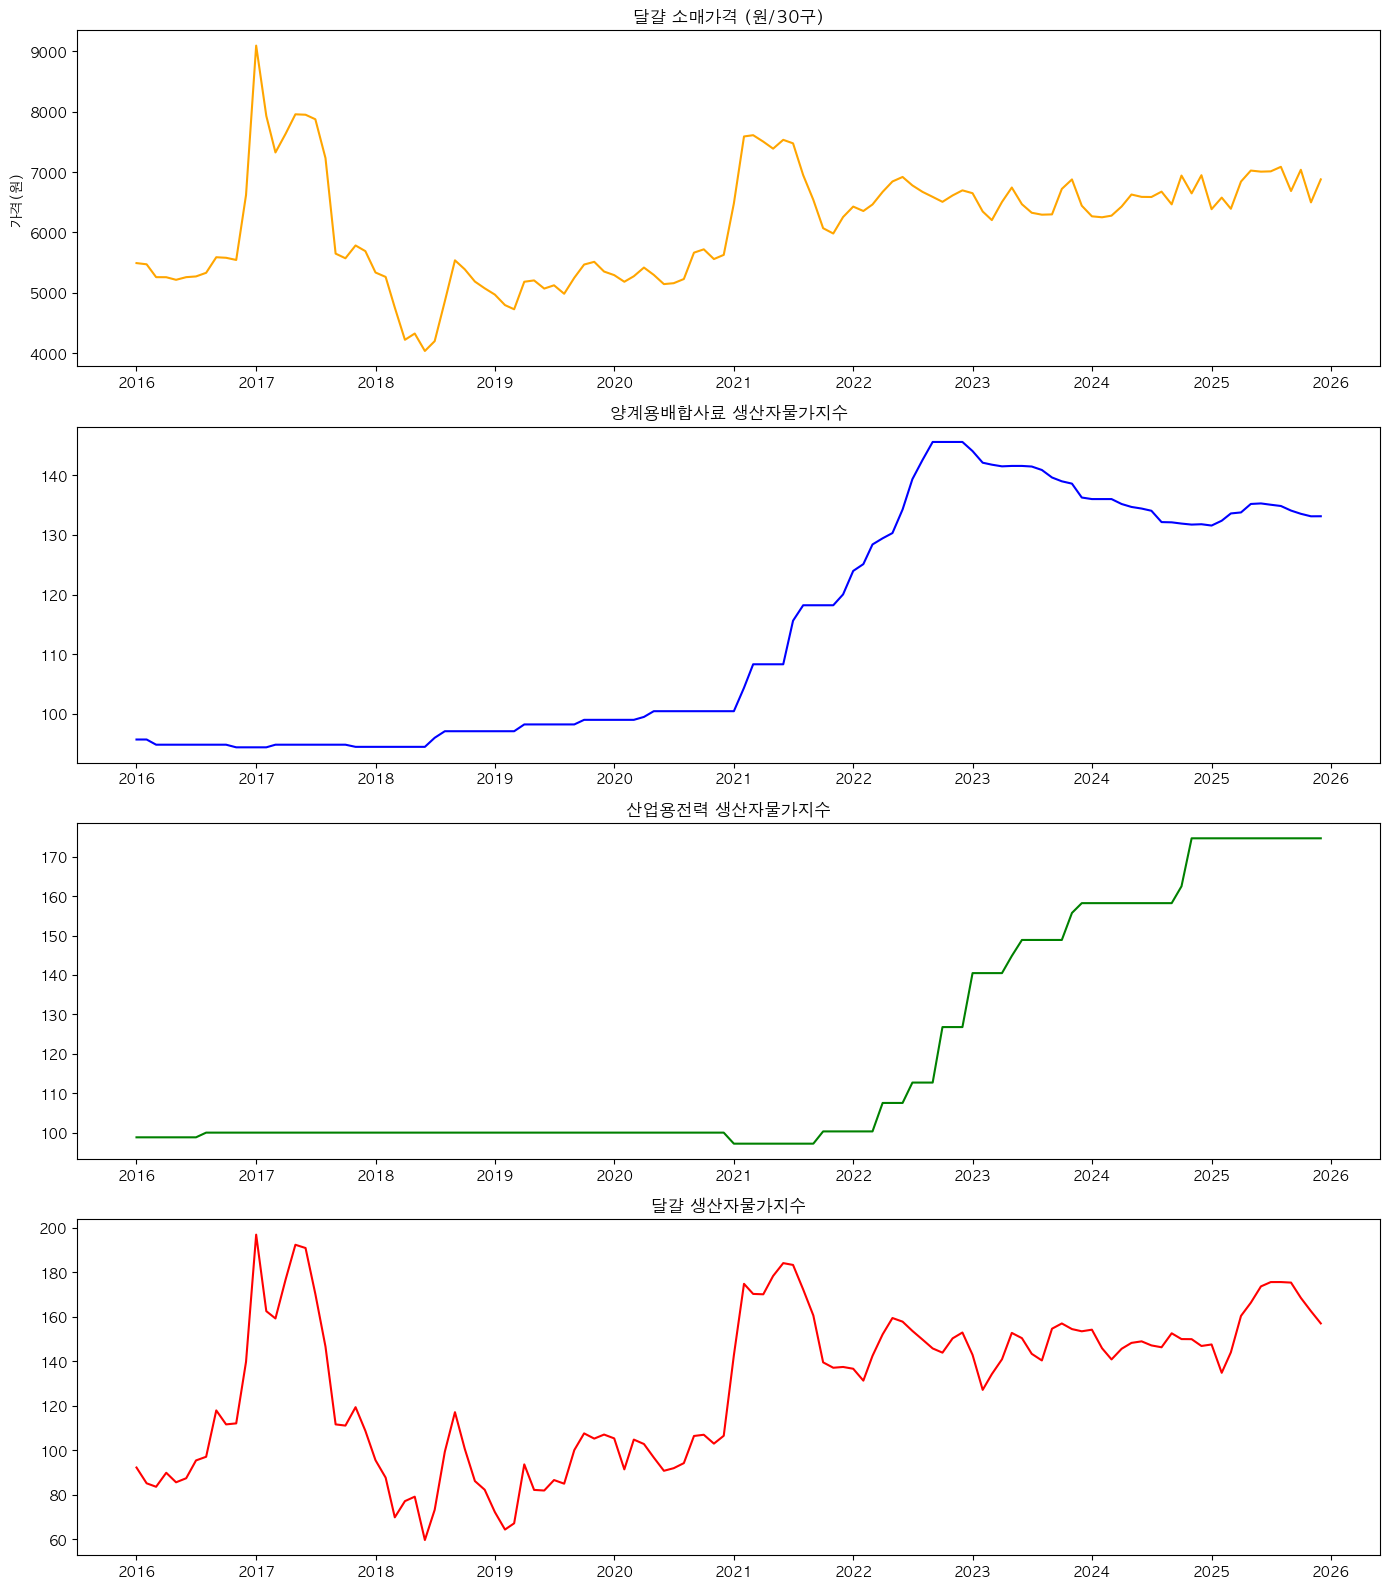

In [6]:
plt.close('all') 

fig, axes = plt.subplots(4, 1, figsize=(14, 16))

# 달걀 소매가격
axes[0].plot(df['year_month'], df['egg_price'], color='orange')
axes[0].set_title('달걀 소매가격 (원/30구)')
axes[0].set_ylabel('가격(원)')

# 사료 생산자물가
axes[1].plot(df['year_month'], df['feed_ppi'], color='blue')
axes[1].set_title('양계용배합사료 생산자물가지수')

# 전력 생산자물가
axes[2].plot(df['year_month'], df['electricity_ppi'], color='green')
axes[2].set_title('산업용전력 생산자물가지수')

# 달걀 생산자물가
axes[3].plot(df['year_month'], df['egg_ppi'], color='red')
axes[3].set_title('달걀 생산자물가지수')

# 달걀 소비자물가는 달걀 생산자물가와 상관 r=0.94로 거의 동일하게 움직이므로 시계열 차트에서 제외한다
# 두 변수 관계는 아래 상관관계 히트맵에서 확인 가능하다

plt.tight_layout()
plt.savefig('../output/figures/time_series_all.png', dpi=150)
plt.show()

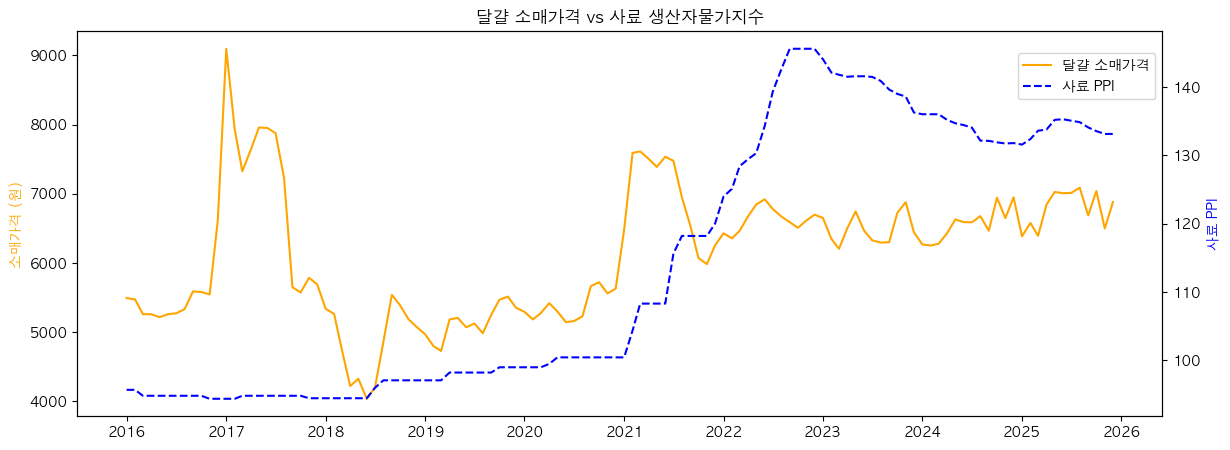

In [7]:
plt.close('all') 

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(df['year_month'], df['egg_price'],
         color='orange', label='달걀 소매가격')
ax1.set_ylabel('소매가격 (원)', color='orange')

ax2 = ax1.twinx()
ax2.plot(df['year_month'], df['feed_ppi'],
         color='blue', linestyle='--', label='사료 PPI')
ax2.set_ylabel('사료 PPI', color='blue')

plt.title('달걀 소매가격 vs 사료 생산자물가지수')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.85))
plt.savefig('../output/figures/egg_vs_feed.png', dpi=150)
plt.show()

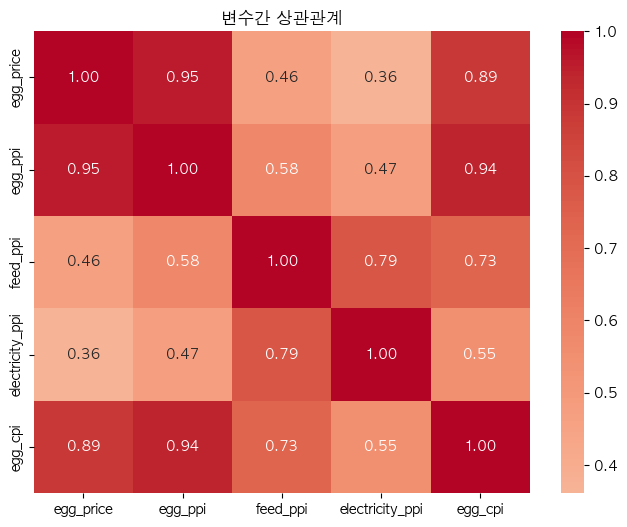

In [8]:
plt.close('all') 

corr = df[['egg_price', 'egg_ppi', 'feed_ppi',
           'electricity_ppi', 'egg_cpi']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('변수간 상관관계')
plt.savefig('../output/figures/correlation_heatmap.png', dpi=150)
plt.show()

### 📌 상관관계 핵심 발견

| 변수 | egg_price와의 상관관계 | 해석 |
|------|---------------|------|
| egg_ppi | **0.95** | 달걀 소매가격과 거의 1:1 동행 |
| egg_cpi | 0.89 | 달걀 소비자물가와도 강하게 연동 |
| feed_ppi | 0.46 | egg_ppi 대비 현저히 낮음 |
| electricity_ppi | 0.36 | 영향력 가장 낮음 |

### 해석

- **egg_ppi(r=0.95)** 는 달걀 소매가격과 가장 강하게 연동  
- feed_ppi(r=0.451)는 electricity_ppi(r=0.352)보다 egg_price와 높은 상관     
  → H2 가설(사료비 영향력 > 전력)의 EDA 단계 근거
- egg_ppi, egg_cpi는 내생성 문제로 모델 피처에서 제외    
  (동행 변수이므로 원인 변수로 해석 불가, 예측 시점에 값 미확보)

급등락 구간:
   year_month  egg_price  price_change_pct
11 2016-12-01       6621         19.404869
12 2017-01-01       9096         37.381060
13 2017-02-01       7932        -12.796834
20 2017-09-01       5650        -21.885801
27 2018-04-01       4222        -11.227923
31 2018-08-01       4860         15.714286
32 2018-09-01       5539         13.971193
60 2021-01-01       6481         15.135903
61 2021-02-01       7591         17.126987


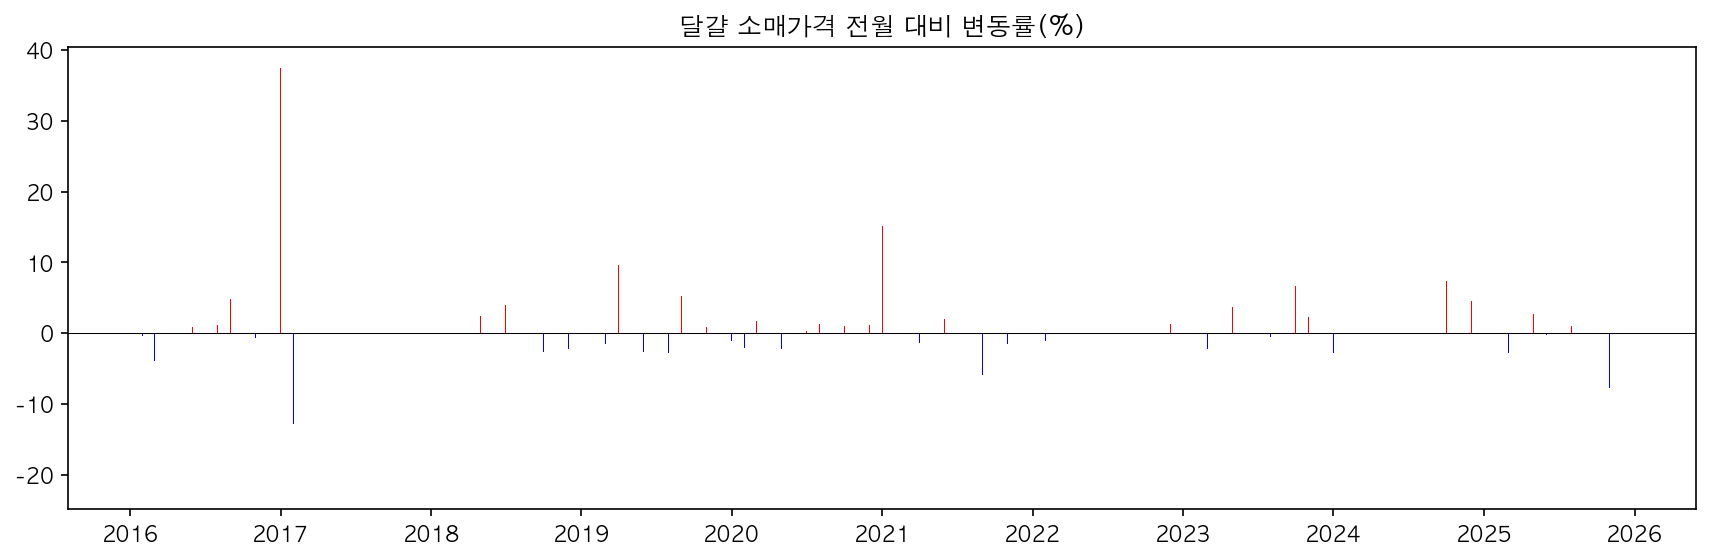

In [9]:
# 전월 대비 가격 변동률
df['price_change_pct'] = df['egg_price'].pct_change() * 100

# 변동률 큰 구간 확인 (±10% 이상)
outliers = df[df['price_change_pct'].abs() > 10]
print("급등락 구간:")
print(outliers[['year_month', 'egg_price', 'price_change_pct']])

plt.close('all') 
plt.figure(figsize=(14, 4), dpi=150)

plt.bar(
    df['year_month'],
    df['price_change_pct'],
    color=df['price_change_pct'].apply(lambda x: 'red' if x > 0 else 'blue'),
)
plt.axhline(y=0, color='black', linewidth=0.5)
plt.title('달걀 소매가격 전월 대비 변동률(%)')

plt.savefig('../output/figures/price_change.png', dpi=150)
plt.show()

IQR 기준 이상치: 1개
   year_month  egg_price
12 2017-01-01       9096


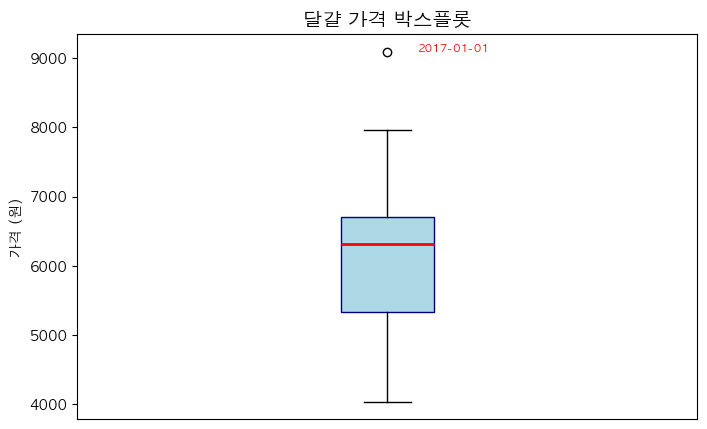

In [10]:
# 이상치 확인
Q1 = df['egg_price'].quantile(0.25)
Q3 = df['egg_price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['egg_price'] < lower) | 
              (df['egg_price'] > upper)]

print(f"IQR 기준 이상치: {len(outliers)}개")
print(outliers[['year_month', 'egg_price']])

plt.close('all') 
fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(df['egg_price'].dropna(), vert=True, patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='navy'),
           medianprops=dict(color='red', linewidth=2),
           flierprops=dict(marker='o', color='red', markersize=6))

for _, row in outliers.iterrows():
    ax.annotate(str(row['year_month'])[:10], 
                xy=(1, row['egg_price']),
                xytext=(1.05, row['egg_price']),
                fontsize=8, color='red')

ax.set_title('달걀 가격 박스플롯', fontsize=14)
ax.set_ylabel('가격 (원)')
ax.set_xticks([])

plt.savefig('../output/figures/outlier_egg_price_boxplot.png', dpi=150)
plt.show()

### 이상치 탐지 결과 해석

IQR 기준 이상치로 **2017년 1월 (9,096원)** 1개가 탐지되었다.   

해당 시점은 2016년 말 전국적으로 확산된 AI 영향으로   
산란계가 대규모 살처분되면서 발생한 **실제 시장 가격 급등 구간**으로 보여진다.   

따라서 데이터 입력 오류나 측정 오류가 아닌 실제 발생한 사건이므로 제거하지 않았다.   
오히려 이 구간은 **H3 가설 - 외부 충격 시 원가 외 요인이 가격을 지배한다**의   
핵심 근거가 되므로 분석에 포함하는 것이 적절하다고 판단했다.

### 정규성 검정

회귀분석 및 상관분석 등 정규성을 가정하는 통계 기법을 적용하기 전   
데이터 분포를 먼저 확인한다.    

- **Shapiro-Wilk**: 현재 데이터가 120개 수준이므로   
  표본이 작을 때(n < 2,000) 가장 강력한 정규성 검정법인 Shapiro-Wilk를 사용한다.
- **Q-Q Plot**: 검정 결과(p-value)만으로는 *어디서* 정규분포를 벗어나는지 알 수 없으므로   
  시각적으로 보완한다.

Shapiro-Wilk 검정
통계량: 0.9743
p-value: 0.0211
정규분포를 따르지 않음 (p < 0.05)


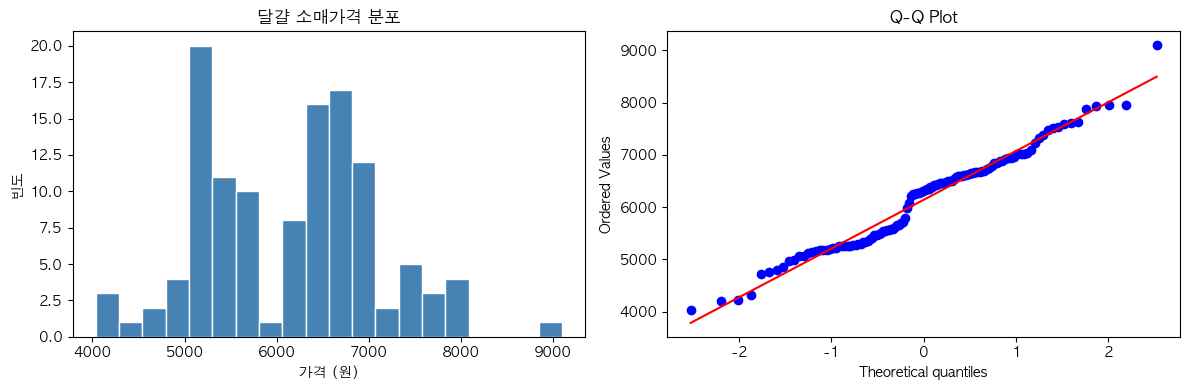

In [11]:
from scipy import stats

# Shapiro-Wilk 검정
stat, p_value = stats.shapiro(df['egg_price'])
print(f"Shapiro-Wilk 검정")
print(f"통계량: {stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value > 0.05:
    print("정규분포를 따름 (p > 0.05)")
else:
    print("정규분포를 따르지 않음 (p < 0.05)")

# Q-Q Plot 시각화
plt.close('all') 

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['egg_price'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('달걀 소매가격 분포')
axes[0].set_xlabel('가격 (원)')
axes[0].set_ylabel('빈도')

stats.probplot(df['egg_price'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()
plt.savefig('../output/figures/normality_check.png', dpi=150)
plt.show()

### 정규성 검정 결과 해석
 
Shapiro-Wilk 검정 결과 통계량 W=0.9743으로 1에 가깝지만   
p-value가 0.0211로 유의수준 0.05를 하회한다.   
따라서 형태는 정규에 가까우나 통계적으로는 **정규분포를 따른다**고 보기 어렵다.   

위의 히스토그램을 보면   
5,000원대와 6,500원대의 **쌍봉우리형 분포**로     
서로 다른 데이터가 혼재할 가능성을 시사한다.   

이는 2016~2020년(사료비 및 전력 원가 안정기, PPI 95~100 수준)과   
2021~2025년(사료비 +36%, 전력 +39% 급등기)   
가격 수준이 분리된 것으로 보인다.   

Q-Q Plot에서 오른쪽 상단 이탈은   
2017년 1월 AI로 인한 이상치로 판단된다.   

따라서 정규성 가정이 충족되지 않아 OLS 회귀분석의 p-value가   
낮아질 수 있으므로 정규성 가정이 없는   
**Random Forest와 XGBoost를 병행 사용**한다.

### 시차 범위를 6개월로 설정한 근거 

시차 변수는 생성 시 해당 개월 수만큼 앞부분이 NaN으로 처리된다.   
현재 사용하는 월별 데이터는 전체 약 120개 수준으로      
12개월 시차 적용 시, 12행이 손실되어 약 10%의 유효 샘플이 줄어든다.   
따라서 샘플 손실을 최소화하면서 유의미한 시차 범위인 6개월치로 먼저 확인하다.   

In [12]:
# 사료비 및 전력 시차별 상관계수 확인
print("=== 사료비 시차별 상관계수 ===")
for lag in range(7):
    corr = df['egg_price'].corr(df['feed_ppi'].shift(lag))
    print(f"사료비 {lag}개월 시차: {corr:.3f}")

print("\n=== 전력 시차별 상관계수 ===")
for lag in range(7):
    corr = df['egg_price'].corr(df['electricity_ppi'].shift(lag))
    print(f"전력 {lag}개월 시차: {corr:.3f}")

=== 사료비 시차별 상관계수 ===
사료비 0개월 시차: 0.462
사료비 1개월 시차: 0.446
사료비 2개월 시차: 0.433
사료비 3개월 시차: 0.420
사료비 4개월 시차: 0.409
사료비 5개월 시차: 0.397
사료비 6개월 시차: 0.384

=== 전력 시차별 상관계수 ===
전력 0개월 시차: 0.361
전력 1개월 시차: 0.352
전력 2개월 시차: 0.345
전력 3개월 시차: 0.340
전력 4개월 시차: 0.335
전력 5개월 시차: 0.329
전력 6개월 시차: 0.322


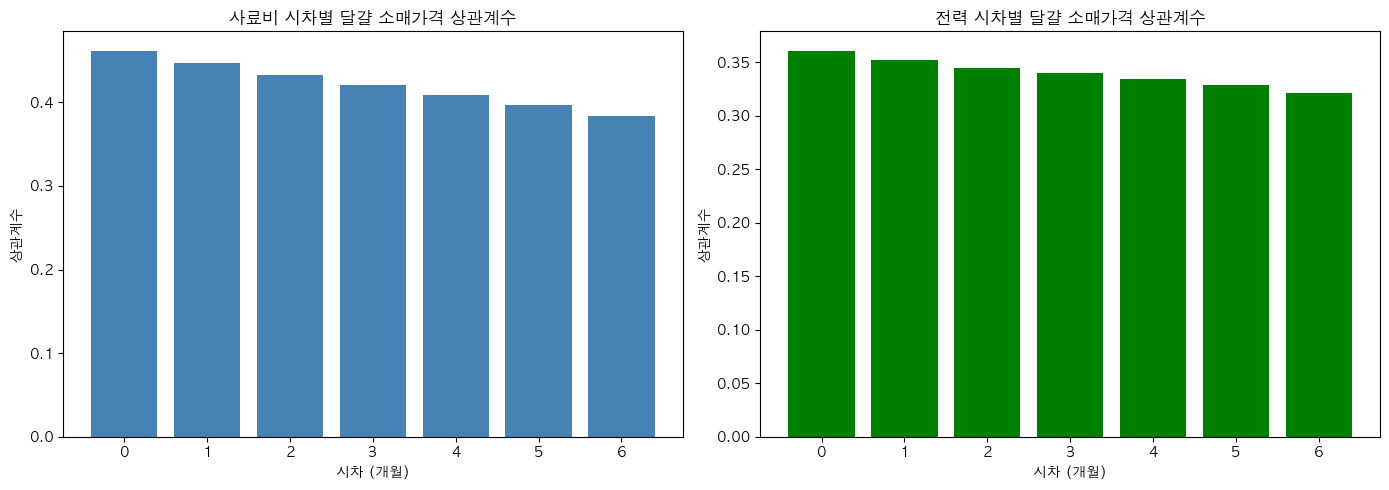

In [13]:
# 시차별 상관계수 시각화
lags = range(7)

feed_corrs = [df['egg_price'].corr(df['feed_ppi'].shift(lag)) for lag in lags]
elec_corrs = [df['egg_price'].corr(df['electricity_ppi'].shift(lag)) for lag in lags]

plt.close('all') 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 사료비
axes[0].bar(lags, feed_corrs, color='steelblue')
axes[0].set_xlabel('시차 (개월)')
axes[0].set_ylabel('상관계수')
axes[0].set_title('사료비 시차별 달걀 소매가격 상관계수')
axes[0].set_xticks(list(lags))

# 전력
axes[1].bar(lags, elec_corrs, color='green')
axes[1].set_xlabel('시차 (개월)')
axes[1].set_ylabel('상관계수')
axes[1].set_title('전력 시차별 달걀 소매가격 상관계수')
axes[1].set_xticks(list(lags))

plt.tight_layout()
plt.savefig('../output/figures/lag_correlation.png', dpi=150)
plt.show()


### 시차별 상관계수 결과 해석
사료비와 전력 모두 **0개월 시차가 최고점**이며 시차 증가 시, 단조 감소한다.   

시차 0~3개월 구간에서는 영향력 감소폭이 완만하여 주요 변동을 잘 반영하고 있지만   
4개월 이후부터는 시차를 확장하더라도 추가적인 설명력 개선이 미미하다.

따라서 **1~3개월 시차 변수**만 생성하여 모델링에 활용한다.  
(0개월은 feed_ppi, electricity_ppi 원변수이므로 포함)


## 📌 EDA 종합 요약

EDA 결과 달걀 소매가격은 사료비 및 전력 원가 변수보다   
생산자물가지수(r=0.95)와 더 강하게 연동되는 패턴이 확인됐다.   
원가 변수 중에서는 feed_ppi(r=0.451)가 electricity_ppi(r=0.352)보다   
egg_price와 더 높은 상관을 보인다.

## 📌 EDA 기반 가설 수립   

### H1
사료비 생산자물가지수는 시차 없이 달걀 소매가격에 즉각 전이된다.

### H2
전력 생산자물가지수보다 사료비의 영향력이 더 크다.

### H3
AI 발생 등 외부 충격 시기에는 원가 외 요인이 가격을 지배한다.



### 시사점 및 다음 단계

**EDA를 통해 확인한 핵심 인사이트**

- 달걀 소매가격은 두 가지 레짐(2016~2020 저가 안정기 / 2021~2025 고가 구조)이   
  혼재하는 구조적 분리 가능성이 있으며, 레짐을 구분하지 않으면   
  단순 원가 기반 예측이 과거 저가 기준으로 편향될 수 있다   
- 원가 변수 중 feed_ppi가 electricity_ppi보다 egg_price와 높은 상관을 보이며   
  두 변수 모두 시차 증가 시 단조 감소한다 -> 사료비 모니터링이 전력비보다 우선순위   
- 전월 대비 ±10% 이상 급변이 총 9회 관측됐으며 AI파동 구간에 집중된다    
  -> 원가 외 요인이 가격을 지배하는 구간이 존재하며 조기 감지 체계가 필요하다
- 생산자물가지수는 가격과 가장 강하게 연동되나 **내생성 문제**로 피처에서 제외한다

**이후 모델링 방향**

- OLS / Random Forest / XGBoost 세 모델로 성능 비교 
- 비정규 분포와 레짐 혼재를 고려하여 RF와 XGBoost를 주 모델로 채택
- 시차 분석 결과(lag1~3 유의)를 반영한 시차 변수를 피처로 포함
- AI파동 구간을 더미변수로, 고가 레짐을 regime 더미로 처리하여   
  외부충격 구간과 구조적 가격 변화를 모델에 반영
- H1/ H2/ H3 세 가설을 04_modeling에서 정량 검증